In [15]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("bmh")
plt.rcParams.update({'font.size': 24})

# %matplotlib inline
# %matplotlib notebook
import seaborn as sns

In [16]:
#Load data
r_i = np.loadtxt('g_NonEq_Yukawa_Nohydro_Pe10_kappa2_Gamma150.dat', usecols=(0))  #Equispaced data, initial list
g_i = np.loadtxt('g_NonEq_Yukawa_Nohydro_Pe10_kappa2_Gamma150.dat', usecols=(1))  #Equisp)aced data, initial list

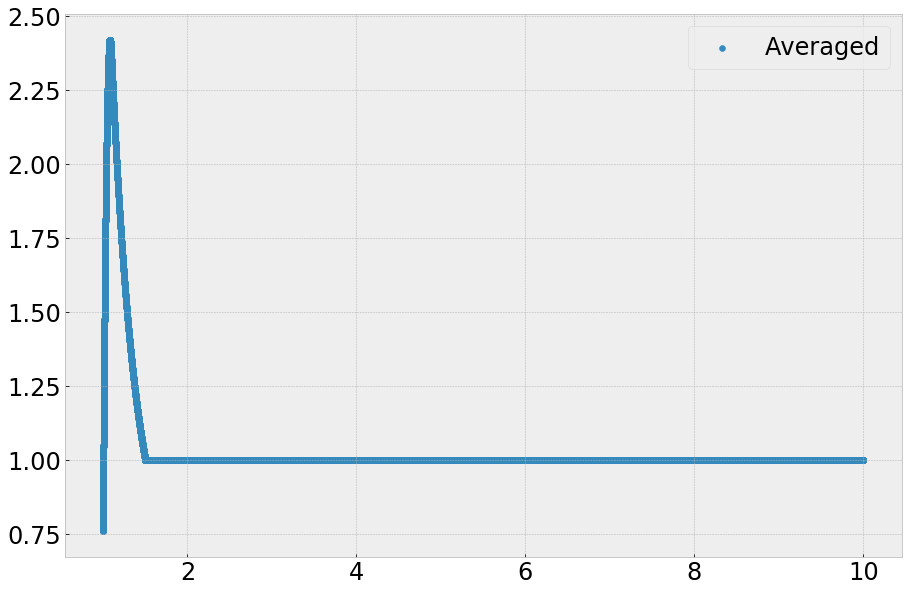

In [17]:
plt.figure(figsize=(15,10))

plt.scatter(r_i,g_i, label = "Averaged")
plt.legend()

### Convertire dati di Luca in dati per input del programma
La griglia di Luca viene presa sempre molto fitta in modo tale che gli integrali vengano calcolati correttamente, 
per esempio in questo caso i dati sono:  
- numero di intervalli della inner region $N_i = 10001$ con ampiezza $\Delta = 10^{-5}$
- numero di intervalli nella outer region $N_e = 89001$ con ampiezza $\Delta = 10^{-4}$

In [18]:
#Input data
delta_x = 0.01                 #delta_x of Francesco_grid
r_in = 1.005049999999999999e+00  #the start point of the Francesco's grid in the inner region
g_in = 9.744299265367050156e-01  #pcf valued at the start point of the Francesco's grid in the inner region
N_tot = r_i.shape[0]
print(N_tot)

99002


##  Luca Output to Francesco input

In [19]:
r_f = r_in #Initial value of the grid list
g_f = g_in #Initial value of the pcf list
c_s = 0    #cycle start
idx = 1    

while(r_in + idx * delta_x < 10):
    for j in range(c_s,N_tot):
        if(r_in + idx*delta_x - r_i[j] < 1e-7 ):
            r_f = np.append(r_f,r_i[j])
            g_f = np.append(g_f,g_i[j])
            c_s = j+1
            #print(r_i[j])
            break
    if(j==N_tot-1):
        break
    idx += 1

N_f = r_f.shape[0]
print(N_f)

900


## Check intervallo stessa ampiezza

<function matplotlib.pyplot.show(*args, **kw)>

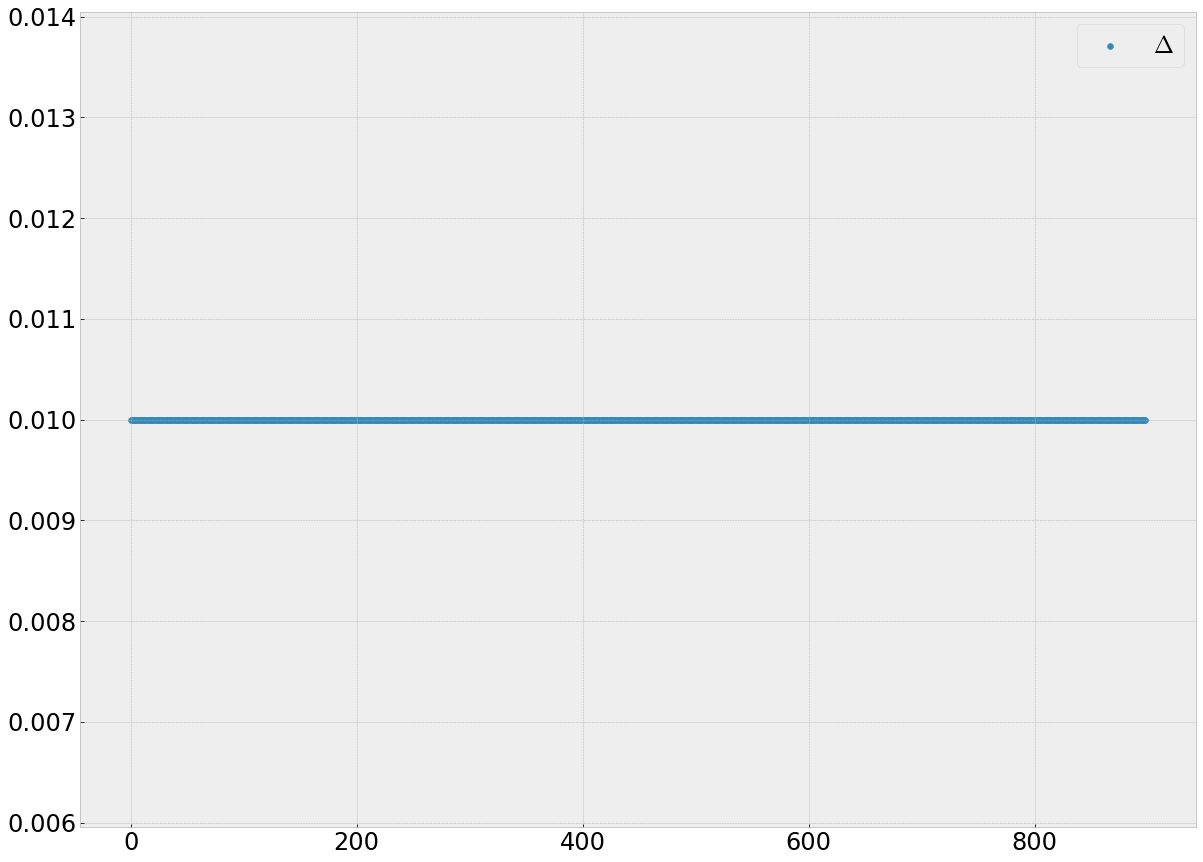

In [20]:
delta = np.zeros(N_f-1)
a = np.arange(N_f-1)

for i in range(N_f-1):
    delta[i] = r_f[i+1] - r_f[i]


plt.figure(figsize=(20,15))
plt.scatter(a,delta, label='$\Delta$')
#plt.ylim(0.01975,0.02025)
#plt.xlim(0,50)
plt.legend()
plt.show

## Scrivi su file 

In [21]:
g_data = np.array([r_f,g_f]).T
np.savetxt('g_EqGrid_deltar_0p01_Yukawa_Nohydro_Pe10_kappa2_Gamma150.in',g_data)

## Potential plot

<function matplotlib.pyplot.show(*args, **kw)>

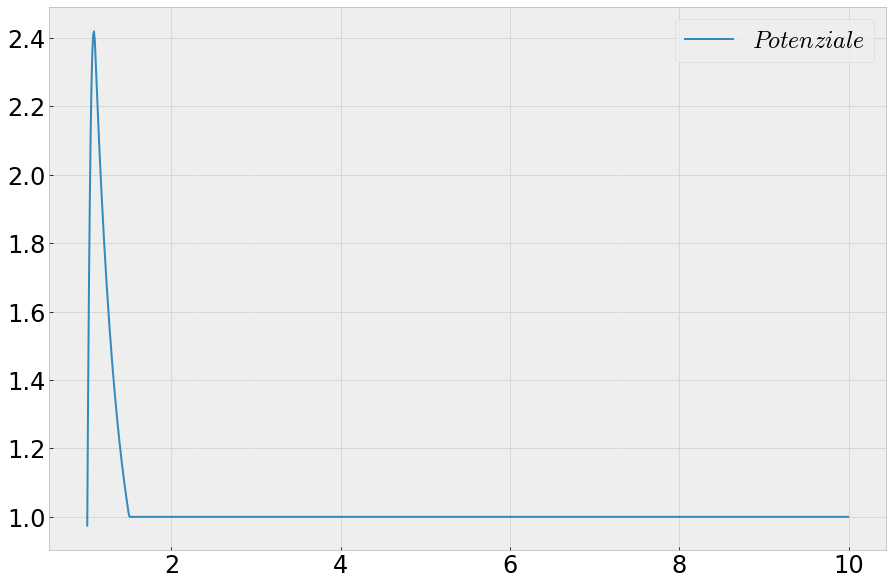

In [22]:
plt.figure(figsize=(15,10))
plt.plot(r_f,g_f, label='$Potenziale$')
#lt.ylim(-0.01,0)
plt.legend()
plt.show

# Check linearity between Francesco grid and input grid

900 900


<function matplotlib.pyplot.show(*args, **kw)>

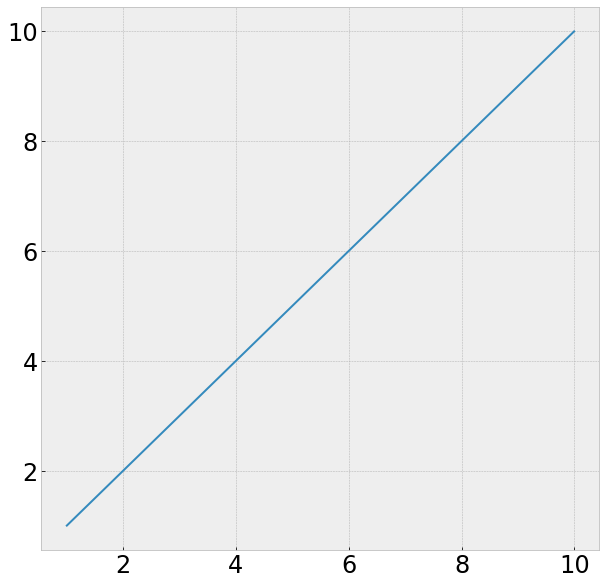

In [24]:
r_grid = np.loadtxt('r0.01.in', usecols=(0))
print(len(r_f),len(r_grid))
plt.figure(figsize=(10,10))
plt.plot(r_f,r_grid)
#plt.ylim(5,5.1)
#plt.xlim(5,5.1)

plt.show

In [ ]:
plt.figure(figsize=(10,10))
plt.scatter(np.arange(r_grid.size),r_grid-r_f)
plt.ylim(-0.0002,0.0002)
plt.xlim(0,1000)

plt.show